In [105]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats  # if you have SciPy
import numpy as np


df = pd.read_csv("../data/sent_matches_deduped_CERWER.csv")
df1 = pd.read_csv("../data/testone.csv")
# df2 = pd.read_csv("../data/difficult_matches_matched2.csv")

In [128]:
df1.iloc[10]

idx                                                                       28
csv_source                                                         highpairs
domain                                                               Fiction
gid                                                                    56600
htid                                                uc2.ark+=13960=t7dr2vk0r
pubdate                                                                 1870
cidx                                                                       0
sidx                                                                      56
cer                                                                 0.016393
wer                                                                   0.0625
target_gsent               " Did not mamma explain to you , then , how su...
target_hsent               " Did uot mamma explain to you , then , how su...
hsent_norm                 did uot mamma explain to you then how sudden i...

In [107]:
df.nunique()

htid                     344
target_hsent           98439
target_gsent           88780
gid                      188
source_row_index      102495
matched_hsent         101257
source_df                  2
csv_source                 2
domain                     4
pubdate                   92
cidx                      10
sidx                    1182
cer                     5969
wer                      932
lev_similarity          6495
cer_gh                  5935
wer_gh                   939
cer_gh_norm             5625
wer_gh_norm              801
cer_gm                  7020
wer_gm                  1026
cer_gm_norm             6768
wer_gm_norm              917
cer_hm                  5245
wer_hm                   607
cer_hm_norm             5241
wer_hm_norm              553
cer_diff_from_orig     23441
wer_diff_from_orig      2619
dtype: int64

In [ ]:
# df1 = df1.rename(columns={
#     "hid": "htid",
#     "gsent": "target_gsent",
#     "hsent": "target_hsent",
#     "matched_honed_lev": "matched_hsent",
#     "matched_honed_lev_score": "matched_hsent_lev_score"
#     })

In [109]:
df = pd.concat([df, df1], ignore_index=True, sort=False)


In [125]:
df["htid"] = (
    df["htid"]
    .str.replace("+", ":", regex=False)
    .str.replace("=", "/", regex=False)
)

In [110]:
print("Rows:", len(df))
print("Duplicate keys:", df.duplicated(subset=["htid", "gid", "cidx", "sidx"]).sum())
print("Rows with no match from df1:",
      df["target_hsent"].isna().sum())

Rows: 164817
Duplicate keys: 0
Rows with no match from df1: 0


In [ ]:
df["cer_new_text"] = df["cer_hm"]
df["wer_new_text"] = df["wer_hm"]

# treat HM_norm as "normalized_text"
df["cer_normalized_text"] = df["cer_hm_norm"]
df["wer_normalized_text"] = df["wer_hm_norm"]

# deltas for new_text vs original
df["cer_delta_new"] = df["cer_diff_from_orig"]
df["wer_delta_new"] = df["wer_diff_from_orig"]

# deltas for normalized vs original (compute from the above)
df["cer_delta_norm"] = df["cer_gm_norm"] - df["cer_hm_norm"]
df["wer_delta_norm"] = df["wer_gm_norm"] - df["wer_hm_norm"]

In [112]:
num_cols = [
    "pubdate",
    "cer", "wer",
    "cer_new_text", "wer_new_text",
    "cer_normalized_text", "wer_normalized_text",
    "cer_delta_new", "cer_delta_norm",
    "wer_delta_new", "wer_delta_norm",
    # optional: keep all the “raw” metrics numeric too
    "cer_gh", "wer_gh",
    "cer_gh_norm", "wer_gh_norm",
    "cer_gm", "wer_gm",
    "cer_gm_norm", "wer_gm_norm",
    "cer_hm", "wer_hm",
    "cer_hm_norm", "wer_hm_norm",
    "cer_diff_from_orig", "wer_diff_from_orig",
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [113]:
tol = 5e-4  # tolerance for float noise

def improvement_stats(delta_series):
    s = delta_series.dropna()
    improved = (s < -tol).sum()
    worse    = (s >  tol).sum()
    same     = ((s >= -tol) & (s <= tol)).sum()
    total    = len(s)
    return {
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(ddof=1),
        "improved": int(improved),
        "worse": int(worse),
        "same": int(same),
        "pct_improved": 100 * improved / total if total else np.nan,
        "pct_worse":    100 * worse    / total if total else np.nan,
        "pct_same":     100 * same     / total if total else np.nan,
        "total": int(total),
    }

In [121]:
print("\n=== CER new_text vs original (cer_delta_new) ===")
cer_new_stats = improvement_stats(df["cer_delta_new"])
print(cer_new_stats)

print("\n=== WER new_text vs original (wer_delta_new) ===")
wer_new_stats = improvement_stats(df["wer_delta_new"])
print(wer_new_stats)

print("\n=== WER GM_norm vs HM_norm (cer_delta_norm) ===")
cer_norm_stats = improvement_stats(df["cer_delta_norm"])
print(cer_norm_stats)

print("\n=== WER GM_norm vs HM_norm (wer_delta_norm) ===")
wer_norm_stats = improvement_stats(df["wer_delta_norm"])
print(wer_norm_stats)


=== CER new_text vs original (cer_delta_new) ===
{'mean': np.float64(-0.0016117532437483937), 'median': np.float64(1.2345678299108263e-11), 'std': np.float64(0.010036001072285333), 'improved': 39038, 'worse': 40433, 'same': 85343, 'pct_improved': np.float64(23.686094627883552), 'pct_worse': np.float64(24.53250330675792), 'pct_same': np.float64(51.78140206535853), 'total': 164814}

=== WER new_text vs original (wer_delta_new) ===
{'mean': np.float64(-0.00692297145020428), 'median': np.float64(1.3877787807814457e-17), 'std': np.float64(0.02780011028995609), 'improved': 25398, 'worse': 39178, 'same': 100238, 'pct_improved': np.float64(15.410098656667516), 'pct_worse': np.float64(23.771038868057325), 'pct_same': np.float64(60.81886247527516), 'total': 164814}

=== WER GM_norm vs HM_norm (cer_delta_norm) ===
{'mean': np.float64(0.027111937928680017), 'median': np.float64(0.016364699006429), 'std': np.float64(0.06036949439701112), 'improved': 38243, 'worse': 112802, 'same': 13772, 'pct_impr

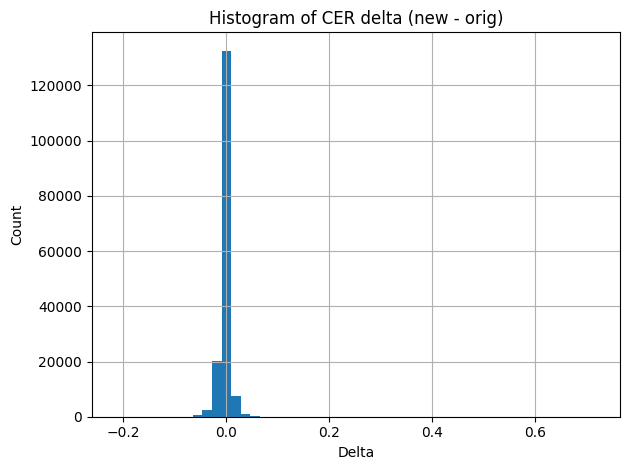

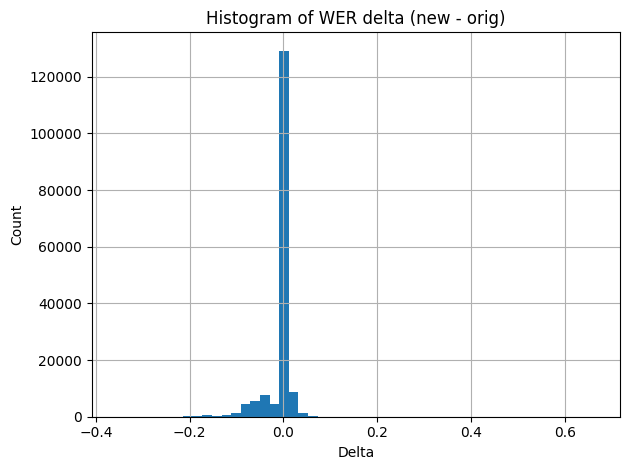

In [122]:
delta_cols = [
    ("CER delta (new - orig)", "cer_delta_new"),
    # ("CER delta (norm - orig)", "cer_delta_norm"),
    ("WER delta (new - orig)", "wer_delta_new"),
    # ("WER delta (norm - orig)", "wer_delta_norm"),
]

for title, col in delta_cols:
    if col in df.columns:
        plt.figure()
        df[col].dropna().hist(bins=50)
        plt.title(f"Histogram of {title}")
        plt.xlabel("Delta")
        plt.ylabel("Count")
        plt.tight_layout()

plt.show()

In [116]:
df["cer_delta_gm"] = df["cer_gm"] - df["cer"]
df["wer_delta_gm"] = df["wer_gm"] - df["wer"]

In [117]:
print("\n=== CER GM vs original ===")
print(improvement_stats(df["cer_delta_gm"]))

print("\n=== WER GM vs original ===")
print(improvement_stats(df["wer_delta_gm"]))


=== CER GM vs original ===
{'mean': np.float64(0.03754603970716459), 'median': np.float64(0.0038120423057623016), 'std': np.float64(0.15276030315639516), 'improved': 42872, 'worse': 92242, 'same': 29700, 'pct_improved': np.float64(26.012353319499557), 'pct_worse': np.float64(55.96733287220746), 'pct_same': np.float64(18.020313808292986), 'total': 164814}

=== WER GM vs original ===
{'mean': np.float64(0.0951728591518982), 'median': np.float64(0.015686274509803907), 'std': np.float64(0.1936885454253217), 'improved': 36952, 'worse': 92789, 'same': 35073, 'pct_improved': np.float64(22.420425449294356), 'pct_worse': np.float64(56.29922215345784), 'pct_same': np.float64(21.280352397247807), 'total': 164814}


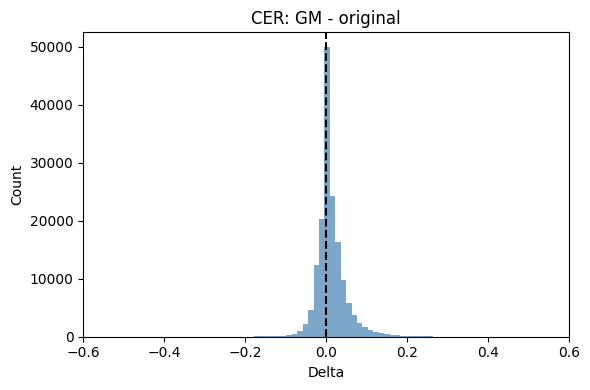

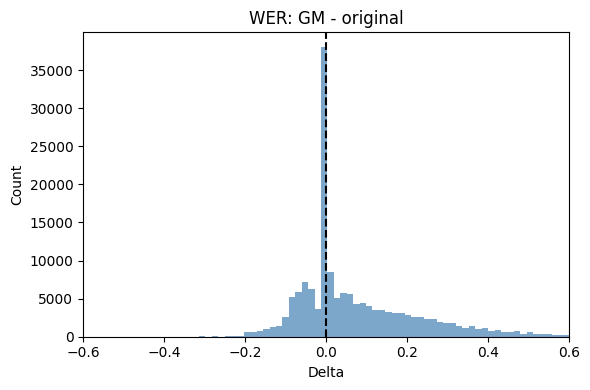

In [119]:
for col, title in [
    ("cer_delta_gm", "CER: GM - original"),
    ("wer_delta_gm", "WER: GM - original")
]:
    s = df[col].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(s, bins=100, color="steelblue", alpha=0.7)
    plt.axvline(0, linestyle="--", color="black")

    plt.title(title)
    plt.xlabel("Delta")
    plt.ylabel("Count")

    # Zoom in on main region
    plt.xlim(-0.6, 0.6)

    plt.tight_layout()

plt.show()


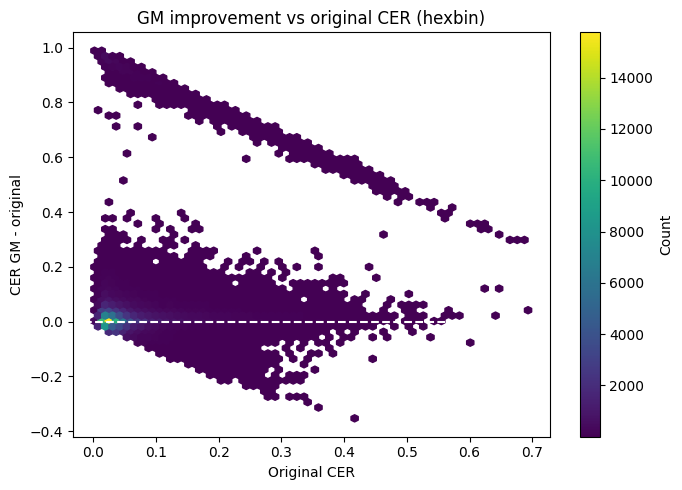

In [123]:
plt.figure(figsize=(7,5))
plt.hexbin(df["cer"], df["cer_delta_gm"], gridsize=60, cmap="viridis", mincnt=1)
plt.axhline(0, linestyle="--", color="white")
plt.colorbar(label="Count")
plt.xlabel("Original CER")
plt.ylabel("CER GM - original")
plt.title("GM improvement vs original CER (hexbin)")
plt.tight_layout()
plt.show()

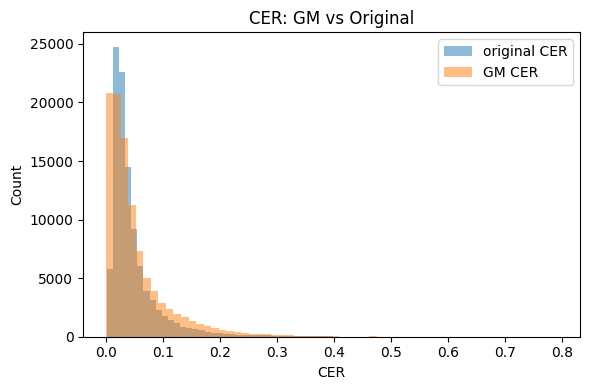

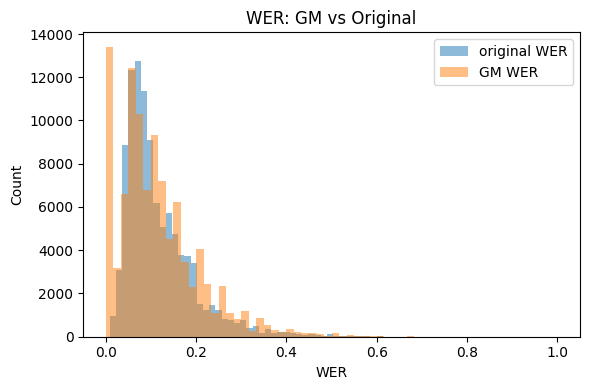

In [49]:
plt.figure(figsize=(6, 4))
plt.hist(df["cer"], bins=60, alpha=0.5, label="original CER")
plt.hist(df["cer_gm"], bins=60, alpha=0.5, label="GM CER")
plt.title("CER: GM vs Original")
plt.xlabel("CER")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["wer"], bins=60, alpha=0.5, label="original WER")
plt.hist(df["wer_gm"], bins=60, alpha=0.5, label="GM WER")
plt.title("WER: GM vs Original")
plt.xlabel("WER")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


In [131]:
df_dates = pd.read_csv(
    "../data/htid_marc_latest_updates.csv",
)
date_cols = ["field_005", "field_974d", "DAT0a", "DAT0b",
             "DAT1a", "DAT1b", "DAT2a", "DAT2b"]

In [160]:
# 1. Ensure all date cols are parsed as datetime with UTC
for col in date_cols:
    if col in df_dates.columns:
        df_dates[col] = pd.to_datetime(df_dates[col], errors="coerce", utc=True)

# 2. Use a UTC-aware cutoff
cutoff = pd.Timestamp("2022-01-01", tz="UTC")

# 3. Keep rows where ANY date col is >= cutoff
mask_recent = df_dates[date_cols].ge(cutoff).any(axis=1)
df_recent = df_dates[mask_recent]

# 4. Get htids and filter main df
recent_htids = set(df_recent["htid"])
df_filtered = df[df["htid"].isin(recent_htids)]

In [161]:
df_filtered.iloc[5500]

htid                                                     uiug.30112042036415
target_hsent               The wmdow , at a little distance from which I ...
target_gsent               The window at a little distance from which I k...
gid                                                                    43111
source_row_index                                                     17866.0
matched_hsent              The window , at a \n little distance from whic...
source_df                                                       ht_matches_4
csv_source                                                         highpairs
domain                                                               Fiction
pubdate                                                                 1875
cidx                                                                       6
sidx                                                                      47
cer                                                                 0.034188

In [215]:
df_filtered.nunique()

htid                          245
target_hsent               107655
target_gsent                98736
gid                           172
source_row_index            67709
matched_hsent              105400
source_df                       2
csv_source                      2
domain                          4
pubdate                        82
cidx                           10
sidx                         1350
cer                          7177
wer                          1170
lev_similarity               5307
cer_gh                       7071
wer_gh                       1182
cer_gh_norm                  6746
wer_gh_norm                  1001
cer_gm                       8233
wer_gm                       1547
cer_gm_norm                  7591
wer_gm_norm                  1049
cer_hm                       6624
wer_hm                       1507
cer_hm_norm                  6147
wer_hm_norm                   996
cer_diff_from_orig          27958
wer_diff_from_orig           3171
idx           

In [162]:
print("\n=== CER GM vs original ===")
print(improvement_stats(df_filtered["cer_delta_gm"]))

print("\n=== WER GM vs original ===")
print(improvement_stats(df_filtered["wer_delta_gm"]))


=== CER GM vs original ===
{'mean': np.float64(0.041715736987741545), 'median': np.float64(0.001325499741111201), 'std': np.float64(0.17215957440809848), 'improved': 36619, 'worse': 58457, 'same': 16324, 'pct_improved': np.float64(32.871633752244165), 'pct_worse': np.float64(52.474865350089765), 'pct_same': np.float64(14.653500897666069), 'total': 111400}

=== WER GM vs original ===
{'mean': np.float64(0.09843197316593648), 'median': np.float64(0.0111111111111111), 'std': np.float64(0.21146721698553447), 'improved': 31429, 'worse': 60607, 'same': 19364, 'pct_improved': np.float64(28.21274685816876), 'pct_worse': np.float64(54.4048473967684), 'pct_same': np.float64(17.382405745062837), 'total': 111400}


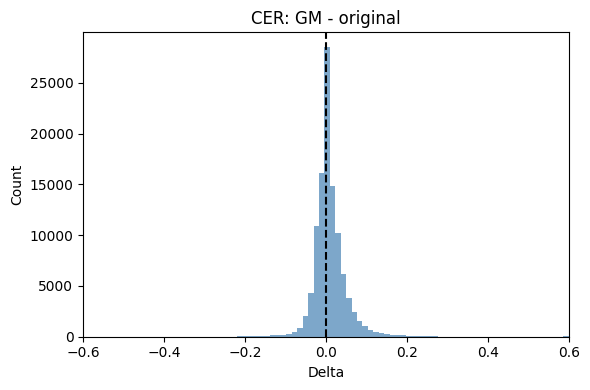

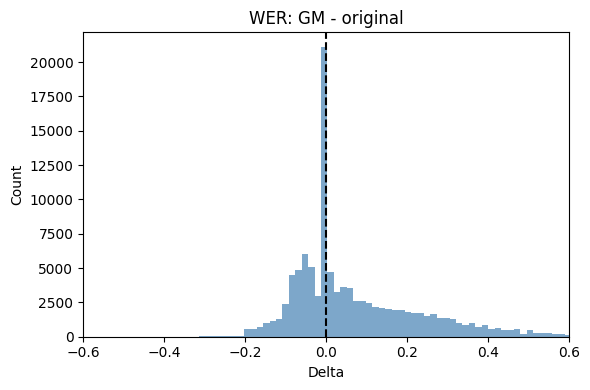

In [174]:
for col, title in [
    ("cer_delta_gm", "CER: GM - original"),
    ("wer_delta_gm", "WER: GM - original")
]:
    s = df_filtered[col].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(s, bins=100, color="steelblue", alpha=0.7)
    plt.axvline(0, linestyle="--", color="black")

    plt.title(title)
    plt.xlabel("Delta")
    plt.ylabel("Count")

    # Zoom in on main region
    plt.xlim(-0.6, 0.6)

    plt.tight_layout()

plt.show()

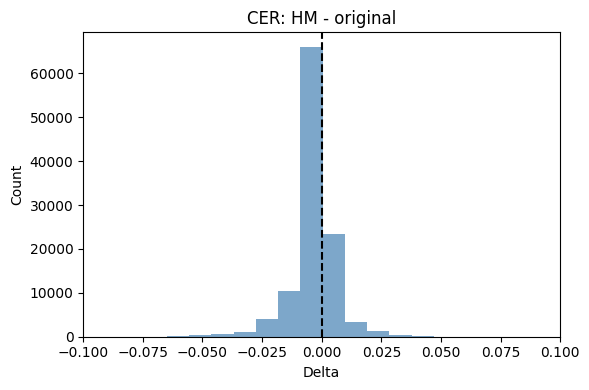

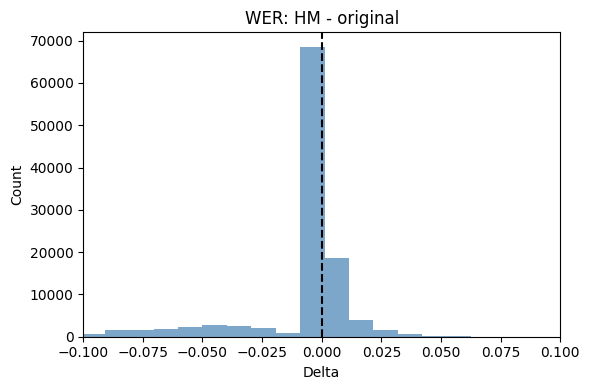

In [216]:
for col, title in [
    ("cer_delta_new", "CER: HM - original"),
    ("wer_delta_new", "WER: HM - original")
]:
    s = df_filtered[col].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(s, bins=100, color="steelblue", alpha=0.7)
    plt.axvline(0, linestyle="--", color="black")

    plt.title(title)
    plt.xlabel("Delta")
    plt.ylabel("Count")

    # Zoom in on main region
    plt.xlim(-0.1, 0.1)

    plt.tight_layout()

plt.show()

In [182]:
df["wer_delta_hm"] = df["wer_hm"] - df["wer"]
df["cer_delta_hm"] = df["cer_hm"] - df["cer"]

In [196]:
def compute_book_improvement_stats(df, delta_col):
    return (
        df.groupby("htid")
          .agg(
              mean_delta   = (delta_col, "mean"),
              median_delta = (delta_col, "median"),
              improved     = (delta_col, lambda s: (s < 0).sum()),
              worse        = (delta_col, lambda s: (s > 0).sum()),
              same         = (delta_col, lambda s: (s == 0).sum()),
              total        = (delta_col, "count"),
          )
          .reset_index()
    )

In [223]:
cer_book_stats = compute_book_improvement_stats(df, "cer_delta_hm")
wer_book_stats = compute_book_improvement_stats(df, "wer_delta_hm")


In [218]:
books_cer_mean_improved = cer_book_stats[cer_book_stats["mean_delta"] < 0]
books_wer_mean_improved = wer_book_stats[wer_book_stats["mean_delta"] < 0]

books_cer_median_improved = cer_book_stats[cer_book_stats["median_delta"] < 0]
books_wer_median_improved = wer_book_stats[wer_book_stats["median_delta"] < 0]

In [219]:
books_cer_majority_improved = cer_book_stats[
    cer_book_stats["improved"] > cer_book_stats["worse"]
]

books_wer_majority_improved = wer_book_stats[
    wer_book_stats["improved"] > wer_book_stats["worse"]
]

In [ ]:
(books_cer_mean_improved.sort_values("mean_delta"))

,htid,mean_delta,median_delta,improved,worse,same,total
131,ien.35556021900030,-0.003711,-0.018182,851,314,8,1173


In [213]:
(books_cer_mean_improved.sort_values("mean_delta")).to_csv("least_improved_books_cer.csv")

In [214]:
(books_wer_mean_improved.sort_values("mean_delta")).to_csv("least_improved_books_wer.csv")
